In [131]:
import sys
from idlelib.colorizer import prog_group_name_to_tag

!{sys.executable} -m pip install -U pip
!{sys.executable} -m pip install -U torch --index-url https://download.pytorch.org/whl/cu128
!{sys.executable} -m pip install optuna

Looking in indexes: https://download.pytorch.org/whl/cu128


In [132]:
import pandas as pd
import optuna
import torch
import Util
import numpy as np
import math

from Util import DatasetGenerator, Visualization, Table
from dataclasses import dataclass
from torch.nn.functional import mse_loss
from torch.nn import Sigmoid
from PIL import Image

from torch.utils.data import random_split, DataLoader, dataset
from torchvision.datasets import ImageFolder
from torchvision import transforms

In [133]:
DEVICE = Util.DEVICE
TYPE = Util.TYPE

# Global visualization utility instance
visualization = Visualization()

In [134]:
def xavier_glorot_init(fan_in, fan_out):
    return (6 / (fan_in + fan_out)) ** 0.5

class MultilayerPerceptron:
    def __init__(self, neurons_per_layer : list [int], alpha : float, gamma : float, max_weights : float):
        self.d, self.m, self.k = neurons_per_layer

        self.alpha = alpha
        self.gamma = gamma
        self.max_weights = max_weights

        self.xavier_glorot_o = xavier_glorot_init(self.d, self.m)
        self.xavier_glorot_s = xavier_glorot_init(self.m, self.k)

        self.Wo = torch.empty(self.d, self.m, dtype=TYPE, device=DEVICE).uniform_(-self.xavier_glorot_o, self.xavier_glorot_o)
        self.Ws = torch.empty(self.m, self.k, dtype=TYPE, device=DEVICE).uniform_(-self.xavier_glorot_s, self.xavier_glorot_s)

        self.Bo = torch.zeros(1, self.m, dtype=TYPE, device=DEVICE)
        self.Bs = torch.zeros(1, self.k, dtype=TYPE, device=DEVICE)

        self.delta_Wo = torch.zeros(1, self.m, dtype=TYPE, device=DEVICE)
        self.delta_Ws = torch.zeros(1, self.k, dtype=TYPE, device=DEVICE)

        self.Po = torch.zeros(1, self.m, dtype=TYPE, device=DEVICE)
        self.Yo = torch.zeros(1, self.m, dtype=TYPE, device=DEVICE)
        self.Ps = torch.zeros(1, self.k, dtype=TYPE, device=DEVICE)
        self.Ys = torch.zeros(1, self.k, dtype=TYPE, device=DEVICE)

        self.activation = Sigmoid()

        self.V_Wo = torch.zeros(self.d, self.m, dtype=TYPE, device=DEVICE)
        self.V_Ws = torch.zeros(self.m, self.k, dtype=TYPE, device=DEVICE)
        self.V_Bo = torch.zeros(self.m, dtype=TYPE, device=DEVICE)
        self.V_Bs = torch.zeros(self.k, dtype=TYPE, device=DEVICE)

    def forward(self, X : torch.Tensor):
        # NxM + 1XM
        self.Po = (X @ self.Wo) + self.Bo
        self.Yo = self.activation(self.Po)
        # NxK + 1xK
        self.Ps = (self.Yo @ self.Ws) + self.Bs
        self.Ys = self.activation(self.Ps)

    def backpropagate_deltas(self, T: torch.Tensor):
        # Output layer       NxK                 NxK   =   NxK
        self.delta_Ws = (self.Ys - T) * (self.Ys * (1 - self.Ys))

        # Hidden layer        NxK               KxM                 NxM       =     NxM
        self.delta_Wo = (self.delta_Ws  @ self.Ws.T) * self.Yo * (1 - self.Yo)

    def update_weights(self, X: torch.Tensor):
        # Hidden Layer DxM                                                 DxN       NxM = DxM
        n = X.shape[0]
        self.V_Wo = self.V_Wo * self.gamma + self.alpha * (1 - self.gamma) * (X.T @ self.delta_Wo) / n
        self.Wo = (self.Wo - self.V_Wo).clamp(-self.max_weights, self.max_weights)

        self.V_Bo = self.V_Bo * self.gamma + self.alpha * (1 - self.gamma) * self.delta_Wo.sum(dim=0) / n
        self.Bo = (self.Bo - self.V_Bo).clamp(-self.max_weights, self.max_weights)

        # Output Layer  MxK                                                 MxN                 NxK   =  MxK
        self.V_Ws = self.V_Ws * self.gamma + self.alpha * (1 - self.gamma) * (self.Yo.T @ self.delta_Ws) / n
        self.Ws = (self.Ws - self.V_Ws).clamp(-self.max_weights, self.max_weights)

        self.V_Bs = self.V_Bs * self.gamma + self.alpha * (1 - self.gamma) * self.delta_Ws.sum(dim=0) / n
        self.Bs = (self.Bs - self.V_Bs).clamp(-self.max_weights, self.max_weights)

    def get_error(self, T: torch.Tensor):
        return mse_loss(self.Ys, T).item()

    def get_accuracy(self, T: torch.Tensor):
        if self.k == 1:
            return (self.Ys.round() == T).float().mean().item()
        return (torch.argmax(self.Ys, dim=1) == torch.argmax(T, dim=1)).float().mean().item()

    def train_mlp(self, num_epochs: int, X : torch.Tensor, T : torch.Tensor, alpha : float | None = None, gamma : float | None = None):
        if alpha is not None:
            self.alpha = alpha
        if gamma is not None:
            self.gamma = gamma
        history_error = []
        history_accuracy = []
        eps = 1e-5
        for _ in range(num_epochs):
            self.forward(X)

            history_error.append(self.get_error(T))
            history_accuracy.append(self.get_accuracy(T))

            self.backpropagate_deltas(T)
            self.update_weights(X)
            if len(history_error) > 1 and abs(history_error[-1] - history_error[-2]) < eps:
                 print("I finished early")
                 break
        self.forward(X)
        history_error.append(self.get_error(T))
        history_accuracy.append(self.get_accuracy(T))

        return history_error, history_accuracy

    def evaluate_batches(self, test_loader) :
        error = []
        accuracy = []
        for X_batch, T_batch in test_loader:
            self.forward(X_batch)
            error.append(self.get_error(T_batch.view(-1, 1).to(DEVICE)))
            accuracy.append(self.get_accuracy(T_batch.view(-1, 1).to(DEVICE)))
        return np.mean(error).item(), np.mean(accuracy).item() ### Luego probar con *batch_size y sumar, luego dividir entre len(data_set)

    def train_batches(self, num_epochs: int, train_loader, alpha : float | None = None, gamma : float | None = None):
        if alpha is not None:
            self.alpha = alpha
        if gamma is not None:
            self.gamma = gamma
        history_error = []
        for _ in range(num_epochs):
            error = []
            for X_batch, T_batch in train_loader:
                self.forward(X_batch)
                self.backpropagate_deltas(T_batch.view(-1, 1).to(DEVICE))
                self.update_weights(X_batch)
                error.append(self.get_error(T_batch.view(-1, 1).to(DEVICE)))
            history_error.append(np.mean(error))
        return history_error

## Test Forward

In [135]:
@dataclass
class DataXOR:
    X = torch.tensor([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ], dtype=TYPE, device=DEVICE)
    M = 2
    T = torch.tensor([
        [1,0],
        [0,1],
        [0,1],
        [1,0]
    ], dtype=TYPE, device=DEVICE)
    class0 = torch.tensor([
        [0,0],
        [1,1]
    ])
    class1 = torch.tensor([
        [1,0],
        [0,1]
    ])


In [136]:
EPSILON = 0.00001

def objective_xor(trial, epsilon : float = EPSILON):
    alpha = trial.suggest_float("alpha", 0.01, 100, log=True)
    gamma = trial.suggest_float("gamma", 0, 1, log=False)
    mp = MultilayerPerceptron([DataXOR.X.shape[1], DataXOR.M, DataXOR.T.shape[1]], alpha, gamma, 1000)
    history_error, history_accuracy = mp.train_mlp(3000, DataXOR.X, DataXOR.T)

    if history_error[-1] < epsilon:
        accuracy = torch.tensor(history_accuracy)
        error = torch.tensor(history_error)

        visualization.make_decision_boundary_plot(mp.Wo, mp.Ws, mp.Bo, mp.Bs ,-0.5, 1.5,-0.5, 1.5, DataXOR.class0, DataXOR.class1)
        visualization.make_error_plot(history_error, f"Alpha : {alpha} Gamma : {gamma} ")

        trial.set_user_attr("accuracy", torch.where(accuracy > 0.99)[0][0].item())
        trial.set_user_attr("error", torch.where(error < epsilon)[0][0].item())

    return history_error[-1]


def study_xor(objective):
    optuna.logging.set_verbosity(optuna.logging.ERROR)

    stud = optuna.create_study(direction="minimize")
    stud.optimize(objective, n_trials=50)

    optuna.visualization.plot_optimization_history(stud).show()
    optuna.visualization.plot_rank(stud).show()
    optuna.visualization.plot_param_importances(stud).show()
    return stud.trials

def show_best_trial(trials, epsilon : float = EPSILON):
    table = Table(pd.DataFrame(), ["Intento","Alpha", "Gamma", "Value", "Precisión","Error"], "Optimizacion")

    for t in trials:
        if t.value < epsilon:

            ind = table.obtain_row_count()

            table.add(ind, "Intento", t.number)
            table.add(ind, "Alpha", t.params["alpha"])
            table.add(ind, "Gamma", t.params["gamma"])
            table.add(ind, "Value", t.value)

            table.add(ind, "Precisión", t.user_attrs["accuracy"])
            table.add(ind, "Error", t.user_attrs["error"])

    table.show()
    table.latex()

# show_best_trial(study_xor(objective_xor))

In [137]:
class Analyze:
    def __init__(self, seed, func):
        self.data, self.labels = func(seed)
        print(self.data.shape[0])
        visualization.make_scatter(self.data[:,0], self.data[:, 1], self.labels)

        self.config = [[20, 0.9], [20, 0], [2, 0.9], [2, 0]]

        self.class0 = self.data[self.labels == 0]
        self.class1 = self.data[self.labels == 1]

    def run_50_iterations(self, min_x : float, max_x : float, min_y : float, max_y : float):

        test_error = [[] for _ in range(len(self.config))]

        for i in range(50):
            train_data, test_data = DatasetGenerator.split_data(0.2, i + 1, self.data, self.labels)

            for j, conf in enumerate(self.config):
                M, gamma = conf
                mlp = MultilayerPerceptron([2, M, 1], 0.01, gamma, 1e5) # con a = 200 y mx = 100 es god
                _ , _ = mlp.train_mlp(1000, train_data[0], train_data[1].view(-1,1)) # con 5000 it es mucho mejor

                mlp.forward(test_data[0])
                test_error[j].append(mlp.get_error(test_data[1].view(-1,1)))

        for i in range(4):
            visualization.make_error_plot(test_error[i], f"M : {self.config[i][0]}  Gamma : {self.config[i][1]}")

    def run_single(self, min_x : float, max_x : float, min_y : float, max_y : float):

        train_data, test_data = DatasetGenerator.split_data(0.2, 0, self.data, self.labels)

        for M, gamma in self.config:
            mlp = MultilayerPerceptron([2, M, 1], 0.01, gamma, 1e5)
            history_error, _ = mlp.train_mlp(10000, train_data[0], train_data[1].view(-1,1))

            visualization.make_decision_boundary_plot(mlp.Wo, mlp.Ws, mlp.Bo, mlp.Bs, min_x, max_x, min_y, max_y, self.class0, self.class1)
            visualization.make_error_plot(history_error, f"M = {M} Gamma = {gamma}")


# separable_analyze = Analyze(444,DatasetGenerator.generate_linearly_separable)
# separable_analyze.run_50_iterations(1.5, 8.5, 1.5, 8.5)
# separable_analyze.run_single(1.5, 8.5, 1.5, 8.5)

# nonseparable_analyze = Analyze(777,DatasetGenerator.generate_nonlinearly_separable)
# nonseparable_analyze.run_50_iterations(-1.5, 2.5, -1.5, 2.5)
# nonseparable_analyze.run_single(-1.5, 2.5, -1.5, 2.5)


In [143]:
class ImageNormalizer:
    def __call__(self, img):
        X = torch.from_numpy(np.array(img)).float()
        eps = 1e-10
        X_norm = X / (X.max() + eps)
        return X_norm.flatten().to(DEVICE)

class Dataset:
    def __init__(self, d: int, train_batch: int, test_batch: int, seed: int, train_size : float = 0.8):
        self.d = d*d*3
        trans = transforms.Compose([
            transforms.Resize((d,d)),
            ImageNormalizer(),
        ])

        self.dataset = ImageFolder (
            "dataset",
            transform = trans
        )

        train_dataset, test_dataset = random_split(
            self.dataset,
            [train_size, 1 - train_size],
            generator = torch.Generator().manual_seed(seed)
        )

        self.train_loader = DataLoader(
            train_dataset,
            batch_size=train_batch,
            shuffle = False
        )

        self.test_loader = DataLoader(
            test_dataset,
            batch_size=test_batch,
            shuffle=False
        )

        print(f"Dataset loaded with d={self.d}, train_batches={len(self.train_loader)}x{self.train_loader.batch_size} and test_batches={len(self.test_loader)}x{self.test_loader.batch_size}")


In [139]:
def test_normalizer_rango_0_1():
    """La salida ℓ∞ debe quedar en [0, 1]."""
    norm = ImageNormalizer()
    img = Image.fromarray((np.random.rand(16, 16, 3) * 255).astype(np.uint8))
    out = norm(img)
    assert out.min().item() >= 0.0
    assert out.max().item() <= 1.0
    print("OK rango [0,1]:", out.min().item(), out.max().item())

# test_normalizer_rango_0_1()

def test_normalizer_max_es_1():
    """Dividir por el máximo => el píxel máximo de la imagen pasa a valer 1."""
    norm = ImageNormalizer()
    arr = np.zeros((8, 8, 3), dtype=np.uint8)
    arr[0, 0] = 200          # un solo píxel con el valor máximo
    out = norm(Image.fromarray(arr))
    assert torch.isclose(out.max(), torch.tensor(1.0), atol=1e-6)
    print("OK max==1:", out.max().item())

# test_normalizer_max_es_1()

In [140]:
@dataclass
class ACRIMA:
    configs = [
          32,   # D = 32*32*3 = 3072
          48,   # D = 48*48*3 = 6912
          64,   # D = 64*64*3 = 12288
    ]
    total = 570

[I 2026-06-02 14:15:07,518] A new study created in memory with name: no-name-ff35bdda-b8c9-4119-92cb-32fd8f4ca00d


Dataset loaded with d=3072, train_size=2 and test_size=10


[I 2026-06-02 14:15:36,760] Trial 0 finished with value: 0.23121178895235062 and parameters: {'alpha': 0.011207430471564674, 'gamma': 0.7707453071349614, 'M': 248}. Best is trial 0 with value: 0.23121178895235062.
[I 2026-06-02 14:16:04,603] Trial 1 finished with value: 0.23732010275125504 and parameters: {'alpha': 0.004171491161544746, 'gamma': 0.9497099759092361, 'M': 104}. Best is trial 0 with value: 0.23121178895235062.
[I 2026-06-02 14:16:34,235] Trial 2 finished with value: 0.14374683052301407 and parameters: {'alpha': 0.15430687512876118, 'gamma': 0.42141050125463564, 'M': 152}. Best is trial 2 with value: 0.14374683052301407.
[I 2026-06-02 14:17:01,382] Trial 3 finished with value: 0.0725659504532814 and parameters: {'alpha': 0.823462223154708, 'gamma': 0.734029615525437, 'M': 346}. Best is trial 3 with value: 0.0725659504532814.
[I 2026-06-02 14:17:30,906] Trial 4 finished with value: 0.2078419104218483 and parameters: {'alpha': 0.03971780124102911, 'gamma': 0.5957967054909885

Dataset loaded with d=3072, train_size=6 and test_size=3


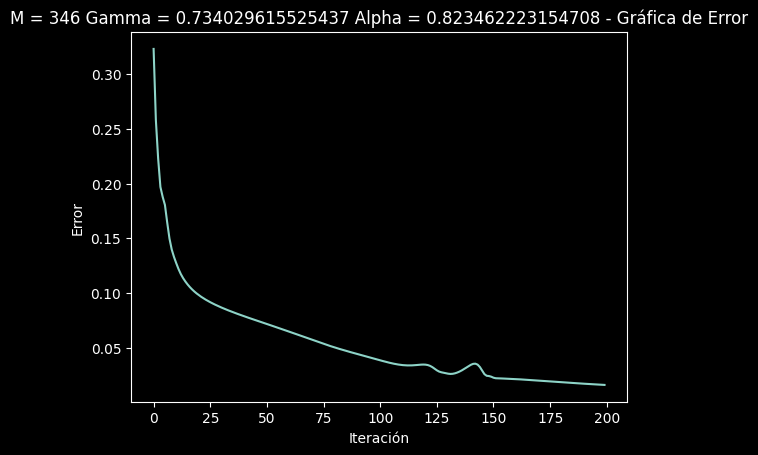

(0.015103450665871302, 0.9916666746139526)


In [141]:
import plotly.express as px

def study_acrima(dataset: Dataset):
    d = round(math.sqrt(dataset.d))
    def objective(trial):
        alpha = trial.suggest_float("alpha", 1e-3, 5, log=True)
        gamma = trial.suggest_float("gamma", 1e-6, 1, log=False)
        M = trial.suggest_int("M", d, ACRIMA.total, log=True) # 2*d + 1 como lim sup, no funciona bien
        mlp = MultilayerPerceptron([dataset.d, M, 1], alpha, gamma, 1000)
        history_error = mlp.train_batches(50, dataset.train_loader, alpha, gamma)
        return history_error[-1]

    optuna.logging.set_verbosity(optuna.logging.INFO)

    stud = optuna.create_study(direction="minimize")
    stud.optimize(objective, n_trials=5)

    optuna.visualization.plot_optimization_history(stud).show()
    optuna.visualization.plot_rank(stud).show()
    optuna.visualization.plot_param_importances(stud).show()

    optuna.visualization.plot_parallel_coordinate(stud).show()

    df = stud.trials_dataframe()

    fig = px.scatter_3d(
        df,
        x="params_gamma",
        y="params_alpha",
        z="params_M",
        color="value"
    )

    fig.show()

    return stud.best_params["alpha"], stud.best_params["gamma"], stud.best_params["M"]

def obtain_best_parameters_acrima():
    for pix in ACRIMA.configs:
        data = Dataset(pix,106,50,1,0.3)
        alpha, gamma, m = study_acrima(data)
        data = Dataset(pix,100,50,1)
        mlp = MultilayerPerceptron([data.d, m, 1], alpha, gamma, 1000)
        history_error = mlp.train_batches(200, data.test_loader, alpha, gamma)
        visualization.make_error_plot(history_error, f"M = {m} Gamma = {gamma} Alpha = {alpha}")
        print(mlp.evaluate_batches(data.test_loader))
        break

obtain_best_parameters_acrima()

# AlexNet